# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The PKMN DB Dataset](https://www.kaggle.com/datasets/malikajrjoyia/pokemon-statstypes-and-abilities-database)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('PKMN_DB.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Pokedex_Number,Pokemon_Name,Generation,Type_1,Type_2,Ability_1,Ability_2,Hidden_Ability,HP,Attack,Defense,Special_Attack,Special_Defense,Speed,BST,Sub_Class,Stage
0,1,Bulbasaur,1,Grass,Poison,Overgrow,NaN,Chlorophyll,45,49,49,65,65,45,318,Starter,1
1,2,Ivysaur,1,Grass,Poison,Overgrow,NaN,Chlorophyll,60,62,63,80,80,60,405,Starter,2
2,3,Venusaur,1,Grass,Poison,Overgrow,NaN,Chlorophyll,80,82,83,100,100,80,525,Starter,3
3,4,Mega_Venusaur,6,Grass,Poison,Thick_Fat,NaN,NaN,80,100,123,122,120,80,625,Starter_Mega_Evolution,3
4,5,Charmander,1,Fire,NaN,Blaze,NaN,Solar_Power,39,52,43,60,50,65,309,Starter,1


## last Five row

In [4]:
df.tail()

,Pokedex_Number,Pokemon_Name,Generation,Type_1,Type_2,Ability_1,Ability_2,Hidden_Ability,HP,Attack,Defense,Special_Attack,Special_Defense,Speed,BST,Sub_Class,Stage
1256,1257,Iron_Crown,9,Steel,Psychic,Quark_Drive,NaN,NaN,90,72,100,122,108,98,590,Paradox,1
1257,1258,Terapagos_Normal_Forme,9,Normal,NaN,Tera_Shift,NaN,NaN,90,65,85,65,85,60,450,Legendary,1
1258,1259,Terapagos_Terastal_Forme,9,Normal,NaN,Tera_Shell,NaN,NaN,95,95,110,105,110,85,600,Legendary_Alternate,1
1259,1260,Terapagos_Stellar_Forme,9,Normal,NaN,Teraform_Zero,NaN,NaN,160,105,110,130,110,85,700,Legendary_Alternate,1
1260,1261,Pecharunt,9,Poison,Ghost,Poison_Puppeteer,NaN,NaN,88,88,160,88,88,88,600,Mythical,1


## Shape of our dataset

In [5]:
df.shape

(1261, 17)

## List out all columns

In [6]:
df.columns

Index(['Pokedex_Number', 'Pokemon_Name', 'Generation', 'Type_1', 'Type_2',
       'Ability_1', 'Ability_2', 'Hidden_Ability', 'HP', 'Attack', 'Defense',
       'Special_Attack', 'Special_Defense', 'Speed', 'BST', 'Sub_Class',
       'Stage'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Pokedex_Number      int64
Pokemon_Name       object
Generation          int64
Type_1             object
Type_2             object
Ability_1          object
Ability_2          object
Hidden_Ability     object
HP                  int64
Attack              int64
Defense             int64
Special_Attack      int64
Special_Defense     int64
Speed               int64
BST                 int64
Sub_Class          object
Stage               int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1261 entries, 0 to 1260
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Pokedex_Number   1261 non-null   int64 
 1   Pokemon_Name     1261 non-null   object
 2   Generation       1261 non-null   int64 
 3   Type_1           1261 non-null   object
 4   Type_2           707 non-null    object
 5   Ability_1        1246 non-null   object
 6   Ability_2        587 non-null    object
 7   Hidden_Ability   938 non-null    object
 8   HP               1261 non-null   int64 
 9   Attack           1261 non-null   int64 
 10  Defense          1261 non-null   int64 
 11  Special_Attack   1261 non-null   int64 
 12  Special_Defense  1261 non-null   int64 
 13  Speed            1261 non-null   int64 
 14  BST              1261 non-null   int64 
 15  Sub_Class        1261 non-null   object
 16  Stage            1261 non-null   int64 
dtypes: int64(10), object(7)
memory us

## Check Null Value

In [9]:
df.isnull().sum()

Pokedex_Number       0
Pokemon_Name         0
Generation           0
Type_1               0
Type_2             554
Ability_1           15
Ability_2          674
Hidden_Ability     323
HP                   0
Attack               0
Defense              0
Special_Attack       0
Special_Defense      0
Speed                0
BST                  0
Sub_Class            0
Stage                0
dtype: int64

## Drop Most Null Features

In [10]:
df.drop(columns=['Type_2', 'Ability_2', 'Hidden_Ability'], inplace=True)

## Ability 1 fill with mode

In [11]:
df["Ability_1"] = df["Ability_1"].fillna(df["Ability_1"].mode()[0])

## Check Dupicate Value

In [12]:
df.duplicated().sum()

np.int64(0)

## Summary

In [13]:
df.describe()

,Pokedex_Number,Generation,HP,Attack,Defense,Special_Attack,Special_Defense,Speed,BST,Stage
count,1261.000000,1261.000000,1261.000000,1261.000000,1261.000000,1261.000000,1261.000000,1261.000000,1261.000000,1261.000000
mean,631.000000,5.179223,71.629659,82.426646,75.957970,74.943695,73.580492,70.901665,449.440127,1.609040
std,364.163654,2.656752,26.912735,32.749585,30.987872,34.215366,28.027524,30.548060,123.732612,0.708372
min,1.000000,1.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,175.000000,1.000000
25%,316.000000,3.000000,55.000000,60.000000,54.000000,50.000000,53.000000,46.000000,335.000000,1.000000
50%,631.000000,5.000000,70.000000,80.000000,70.000000,69.000000,70.000000,70.000000,472.000000,1.000000
75%,946.000000,8.000000,85.000000,102.000000,95.000000,95.000000,90.000000,92.000000,530.000000,2.000000
max,1261.000000,9.000000,255.000000,190.000000,250.000000,216.000000,250.000000,200.000000,1125.000000,3.000000


# EDA

In [14]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

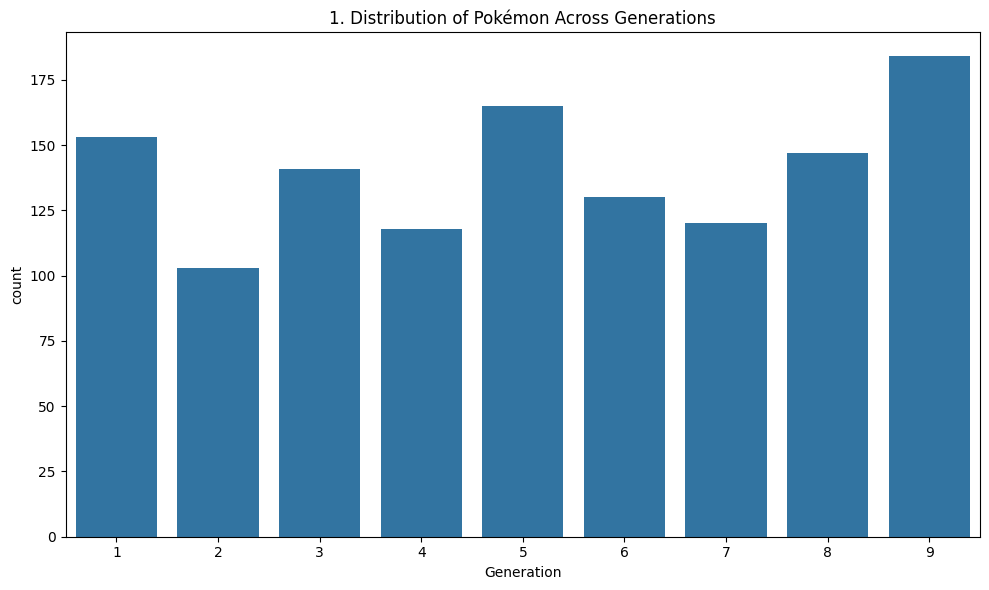

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Generation', order=sorted(df['Generation'].unique()))
plt.title(f'{plot_no}. Distribution of Pokémon Across Generations')
show_fig()
plot_no += 1

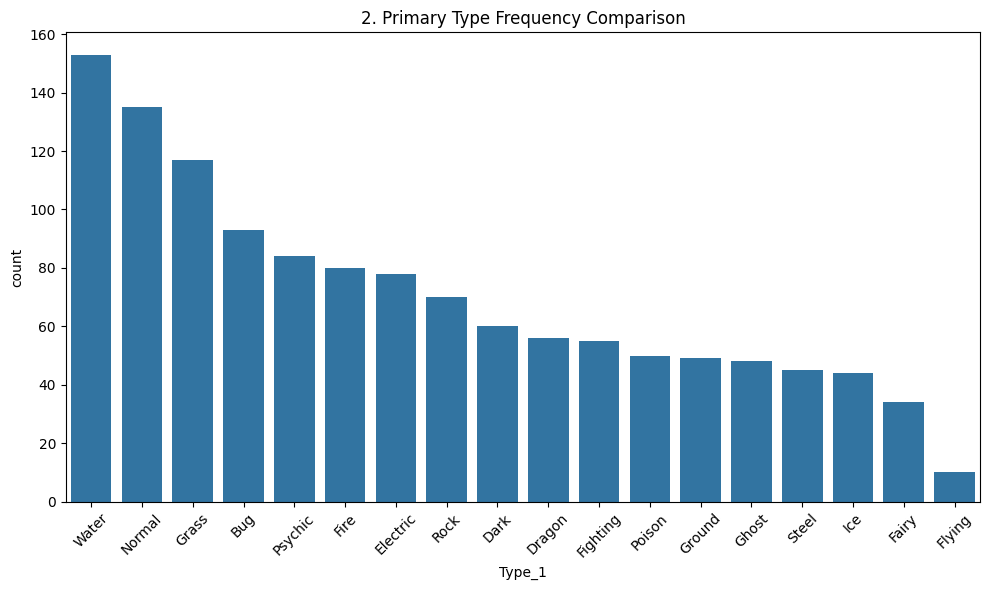

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Type_1', order=df['Type_1'].value_counts().index)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Primary Type Frequency Comparison')
show_fig()
plot_no += 1

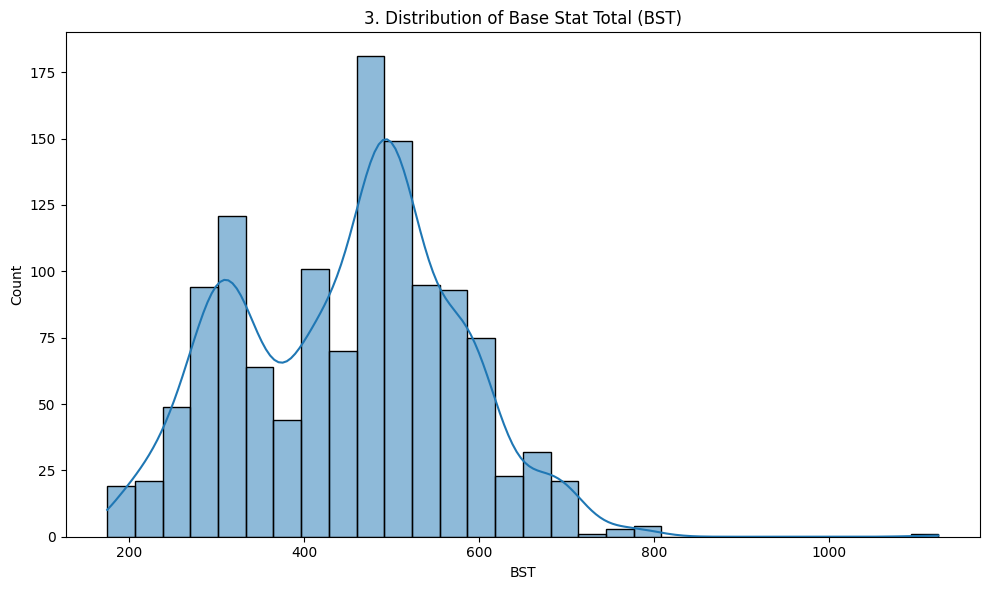

In [17]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['BST'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Base Stat Total (BST)')
show_fig()
plot_no += 1

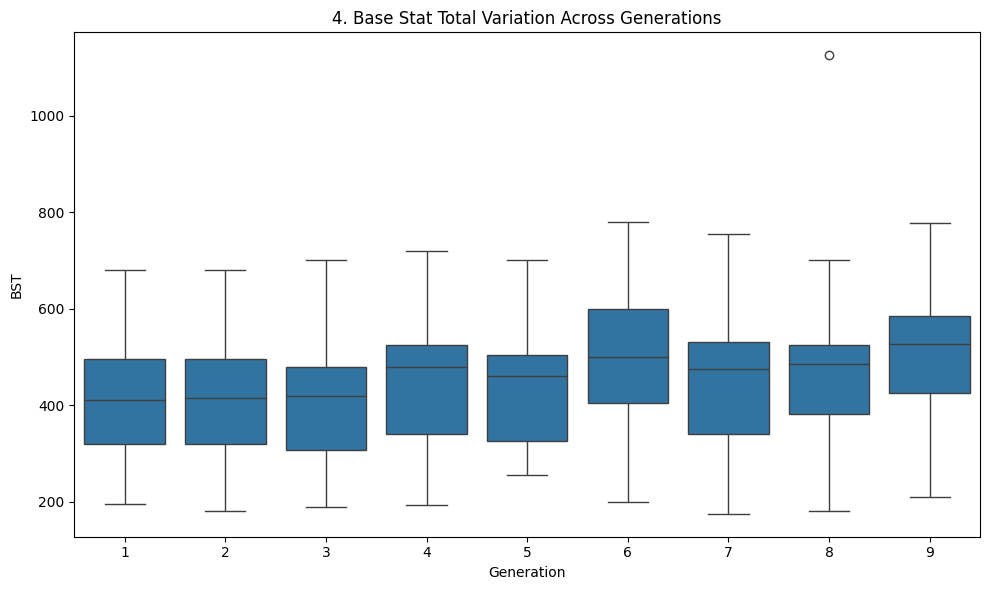

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Generation', y='BST')
plt.title(f'{plot_no}. Base Stat Total Variation Across Generations')
show_fig()
plot_no += 1

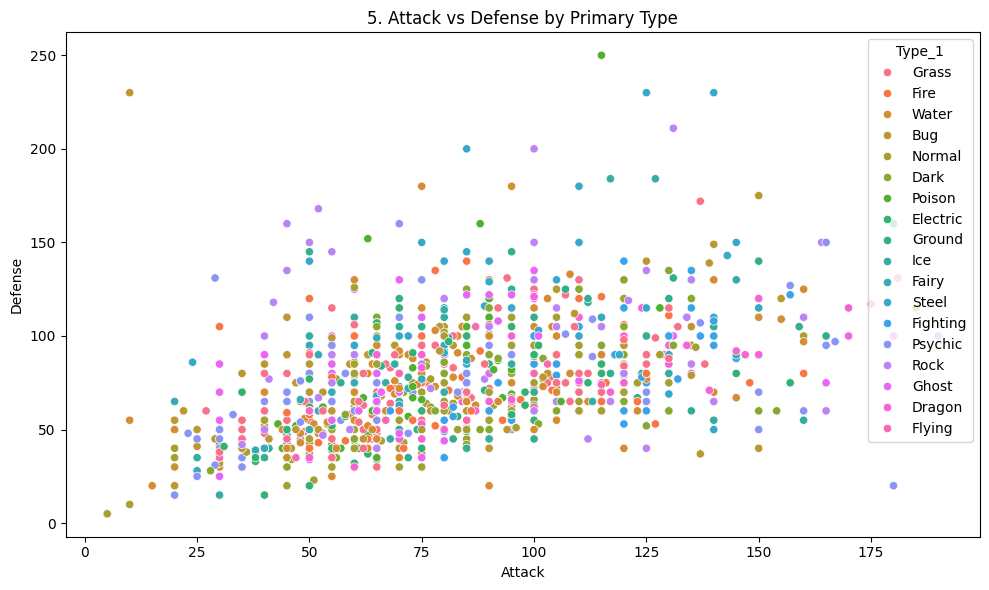

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Attack', y='Defense', hue='Type_1')
plt.title(f'{plot_no}. Attack vs Defense by Primary Type')
show_fig()
plot_no += 1

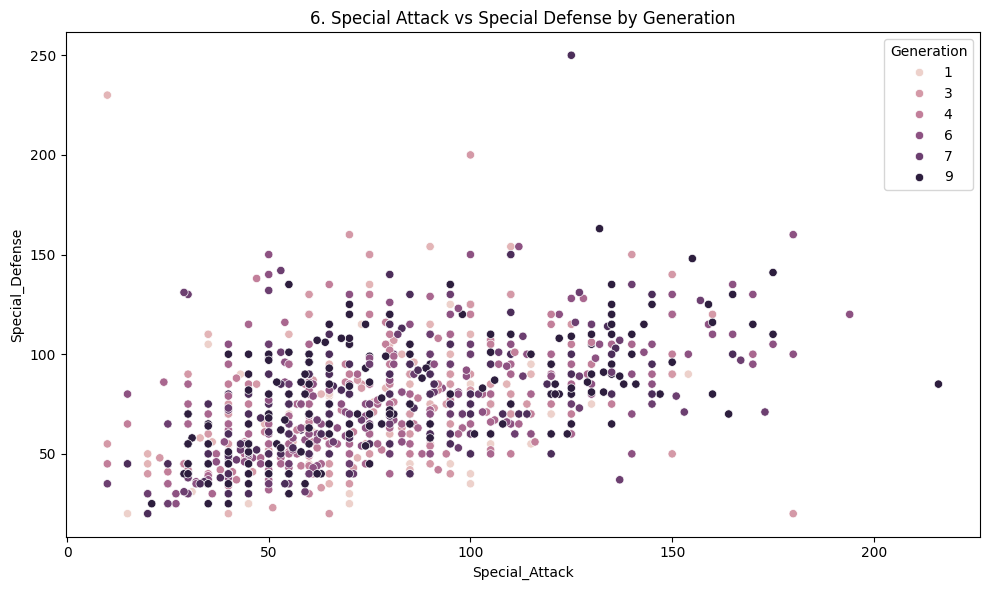

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Special_Attack', y='Special_Defense', hue='Generation')
plt.title(f'{plot_no}. Special Attack vs Special Defense by Generation')
show_fig()
plot_no += 1

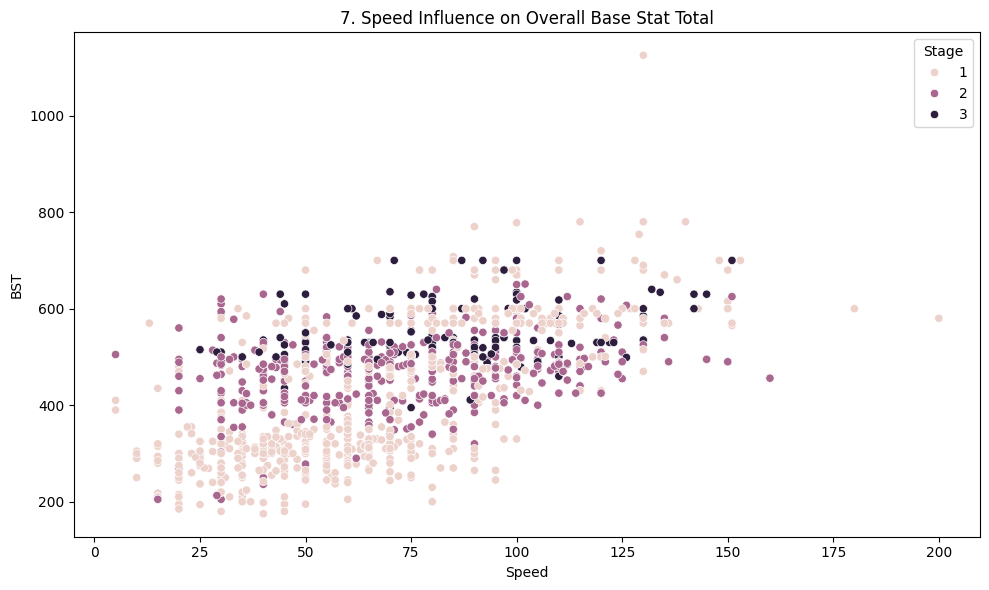

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Speed', y='BST', hue='Stage')
plt.title(f'{plot_no}. Speed Influence on Overall Base Stat Total')
show_fig()
plot_no += 1

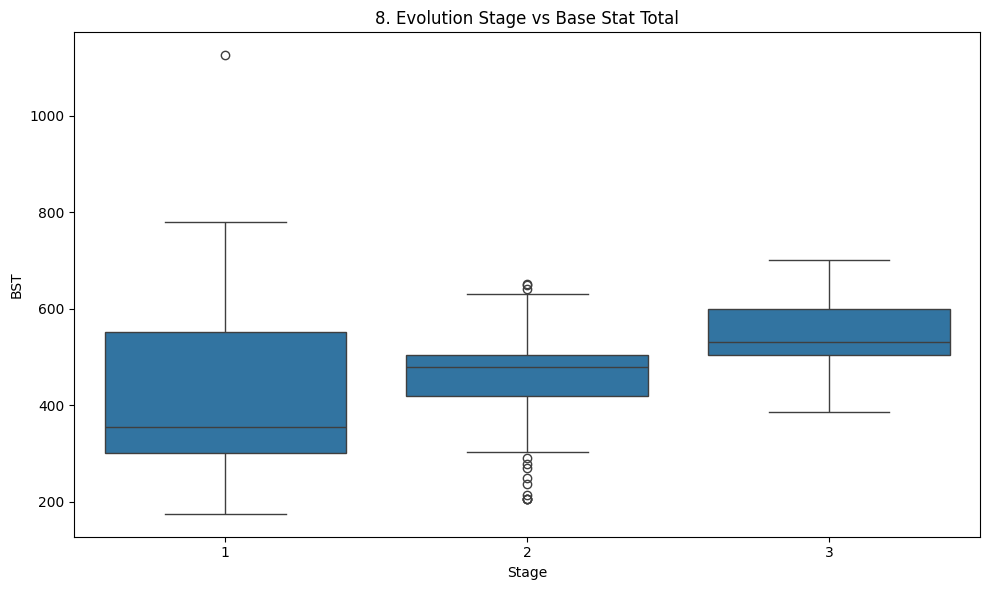

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Stage', y='BST')
plt.title(f'{plot_no}. Evolution Stage vs Base Stat Total')
show_fig()
plot_no += 1

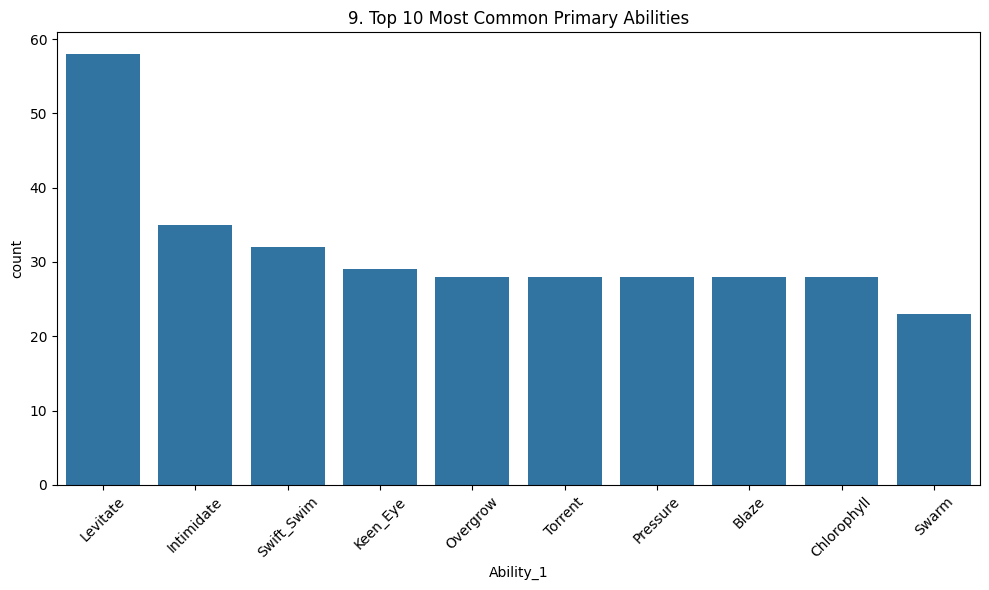

In [23]:
fig = plt.figure(figsize=(10,6))
top_abilities = df['Ability_1'].value_counts().head(10).index
sns.countplot(data=df[df['Ability_1'].isin(top_abilities)], x='Ability_1', order=top_abilities)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Top 10 Most Common Primary Abilities')
show_fig()
plot_no += 1

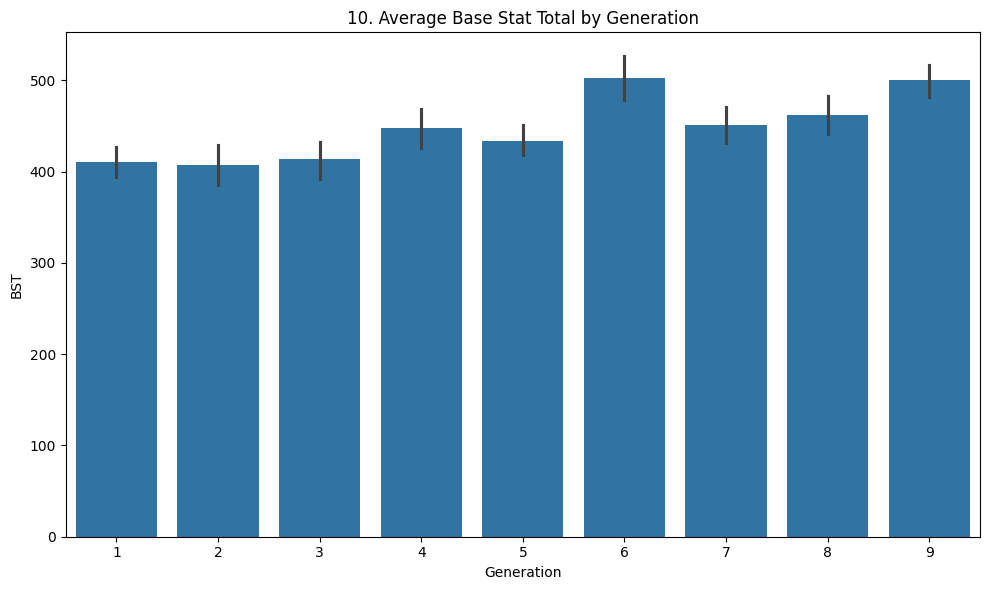

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Generation', y='BST', estimator='mean')
plt.title(f'{plot_no}. Average Base Stat Total by Generation')
show_fig()
plot_no += 1

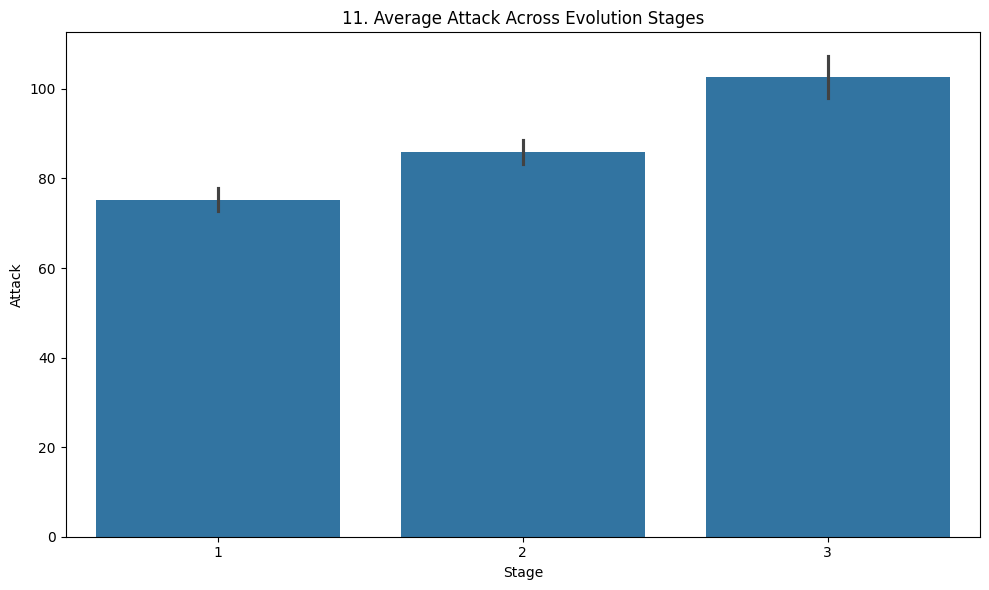

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Stage', y='Attack', estimator='mean')
plt.title(f'{plot_no}. Average Attack Across Evolution Stages')
show_fig()
plot_no += 1

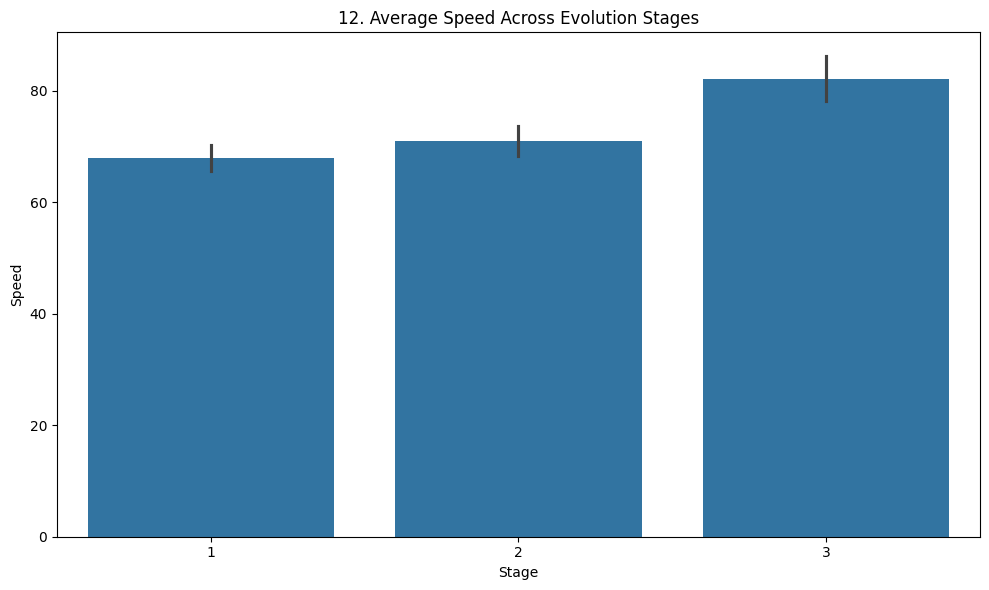

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Stage', y='Speed', estimator='mean')
plt.title(f'{plot_no}. Average Speed Across Evolution Stages')
show_fig()
plot_no += 1

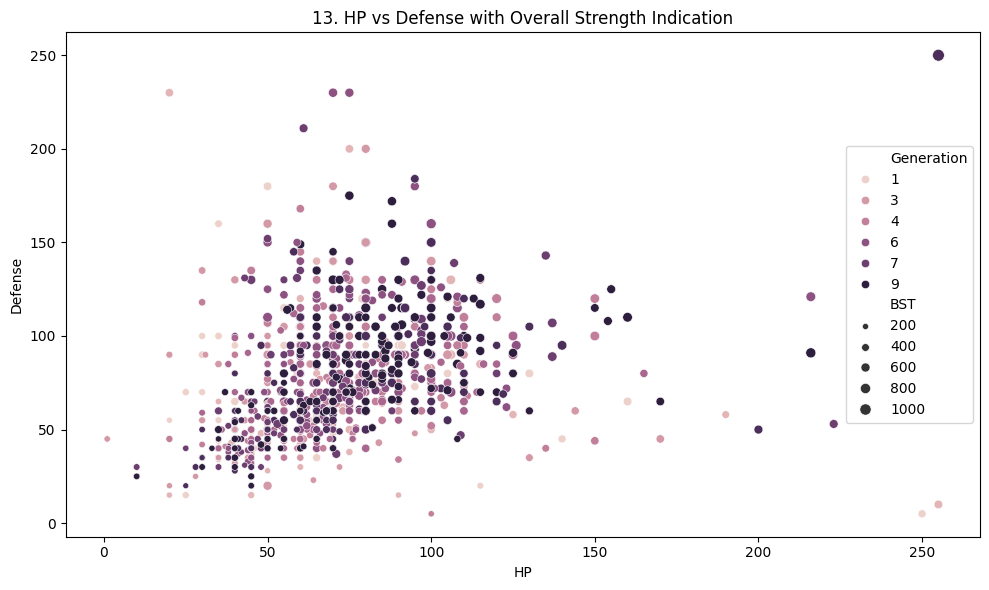

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='HP', y='Defense', size='BST', hue='Generation')
plt.title(f'{plot_no}. HP vs Defense with Overall Strength Indication')
show_fig()
plot_no += 1

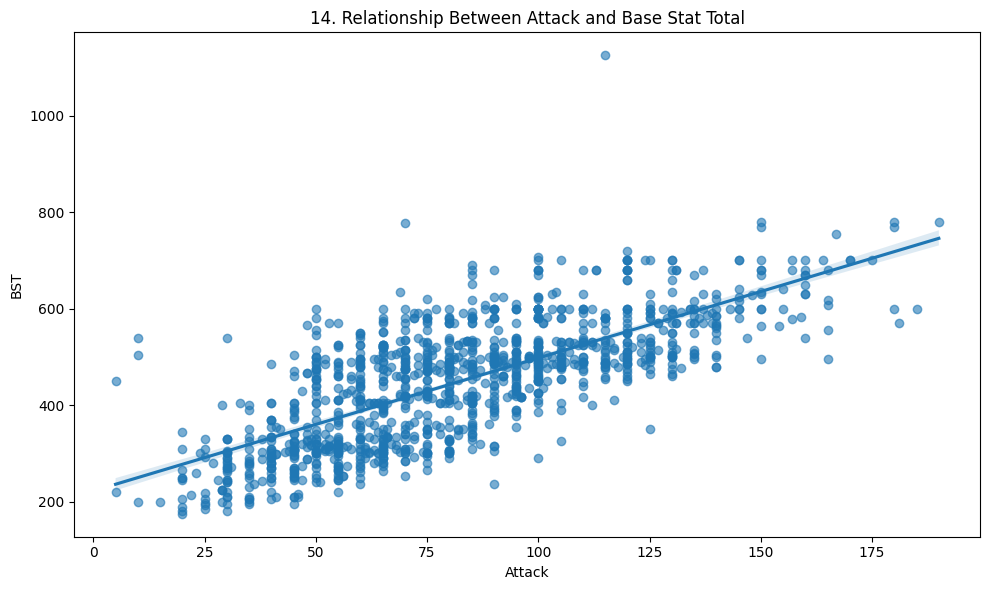

In [28]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='Attack', y='BST', scatter_kws={'alpha':0.6})
plt.title(f'{plot_no}. Relationship Between Attack and Base Stat Total')
show_fig()
plot_no += 1

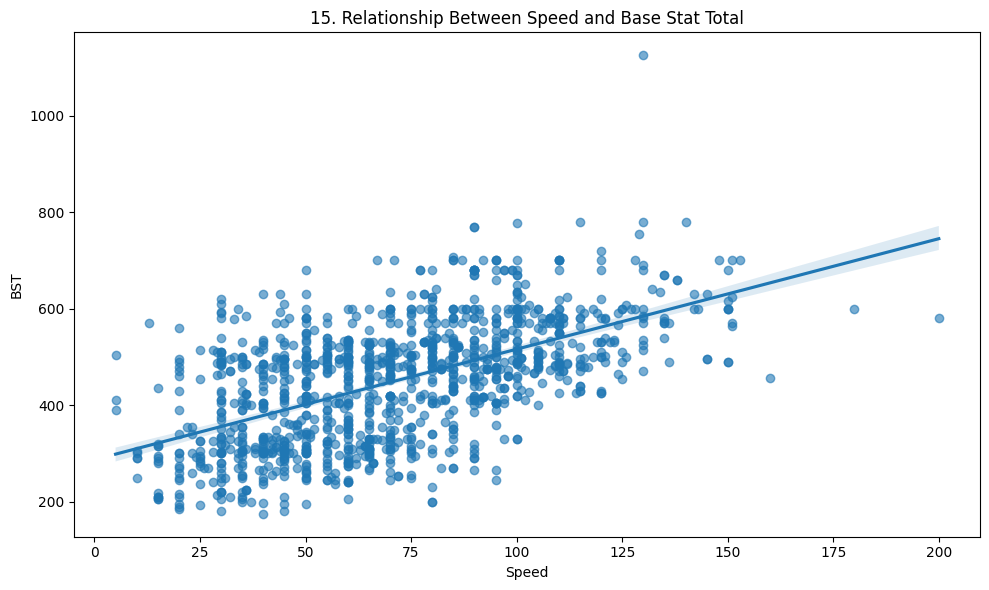

In [29]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='Speed', y='BST', scatter_kws={'alpha':0.6})
plt.title(f'{plot_no}. Relationship Between Speed and Base Stat Total')
show_fig()
plot_no += 1

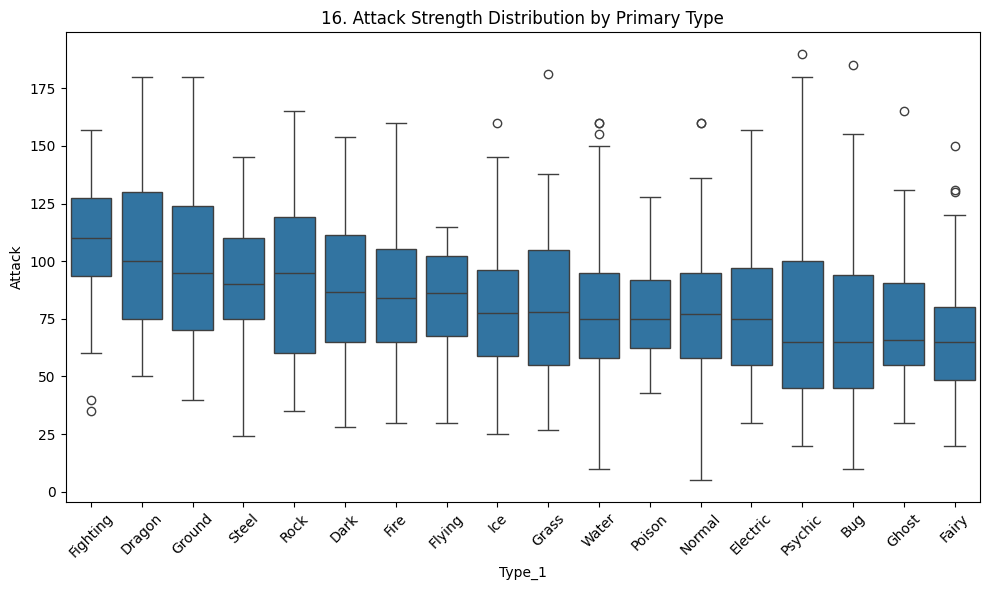

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Type_1', y='Attack', order=df.groupby('Type_1')['Attack'].mean().sort_values(ascending=False).index)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Attack Strength Distribution by Primary Type')
show_fig()
plot_no += 1

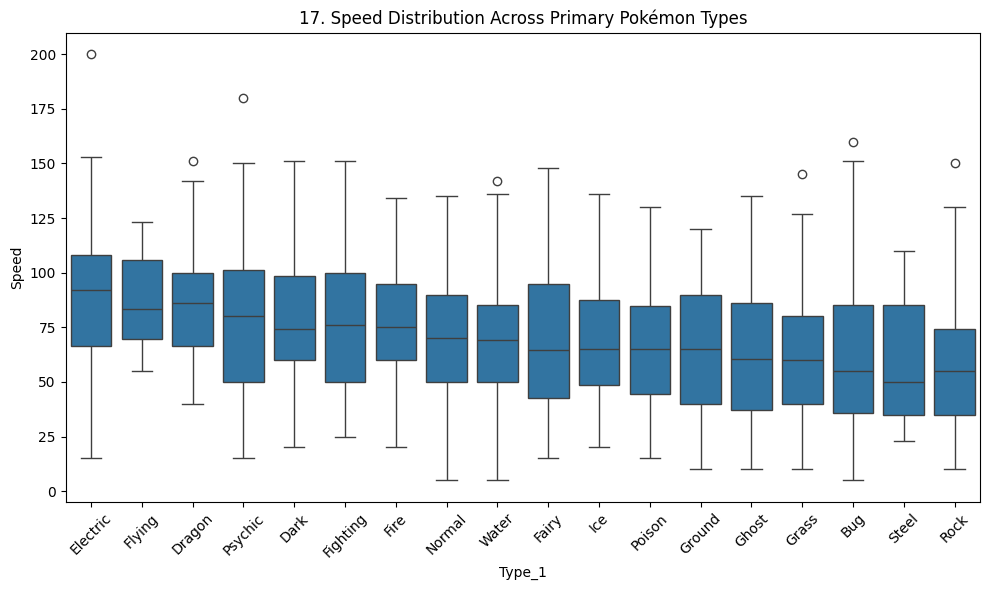

In [31]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Type_1', y='Speed', order=df.groupby('Type_1')['Speed'].mean().sort_values(ascending=False).index)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Speed Distribution Across Primary Pokémon Types')
show_fig()
plot_no += 1

<Figure size 1000x600 with 0 Axes>

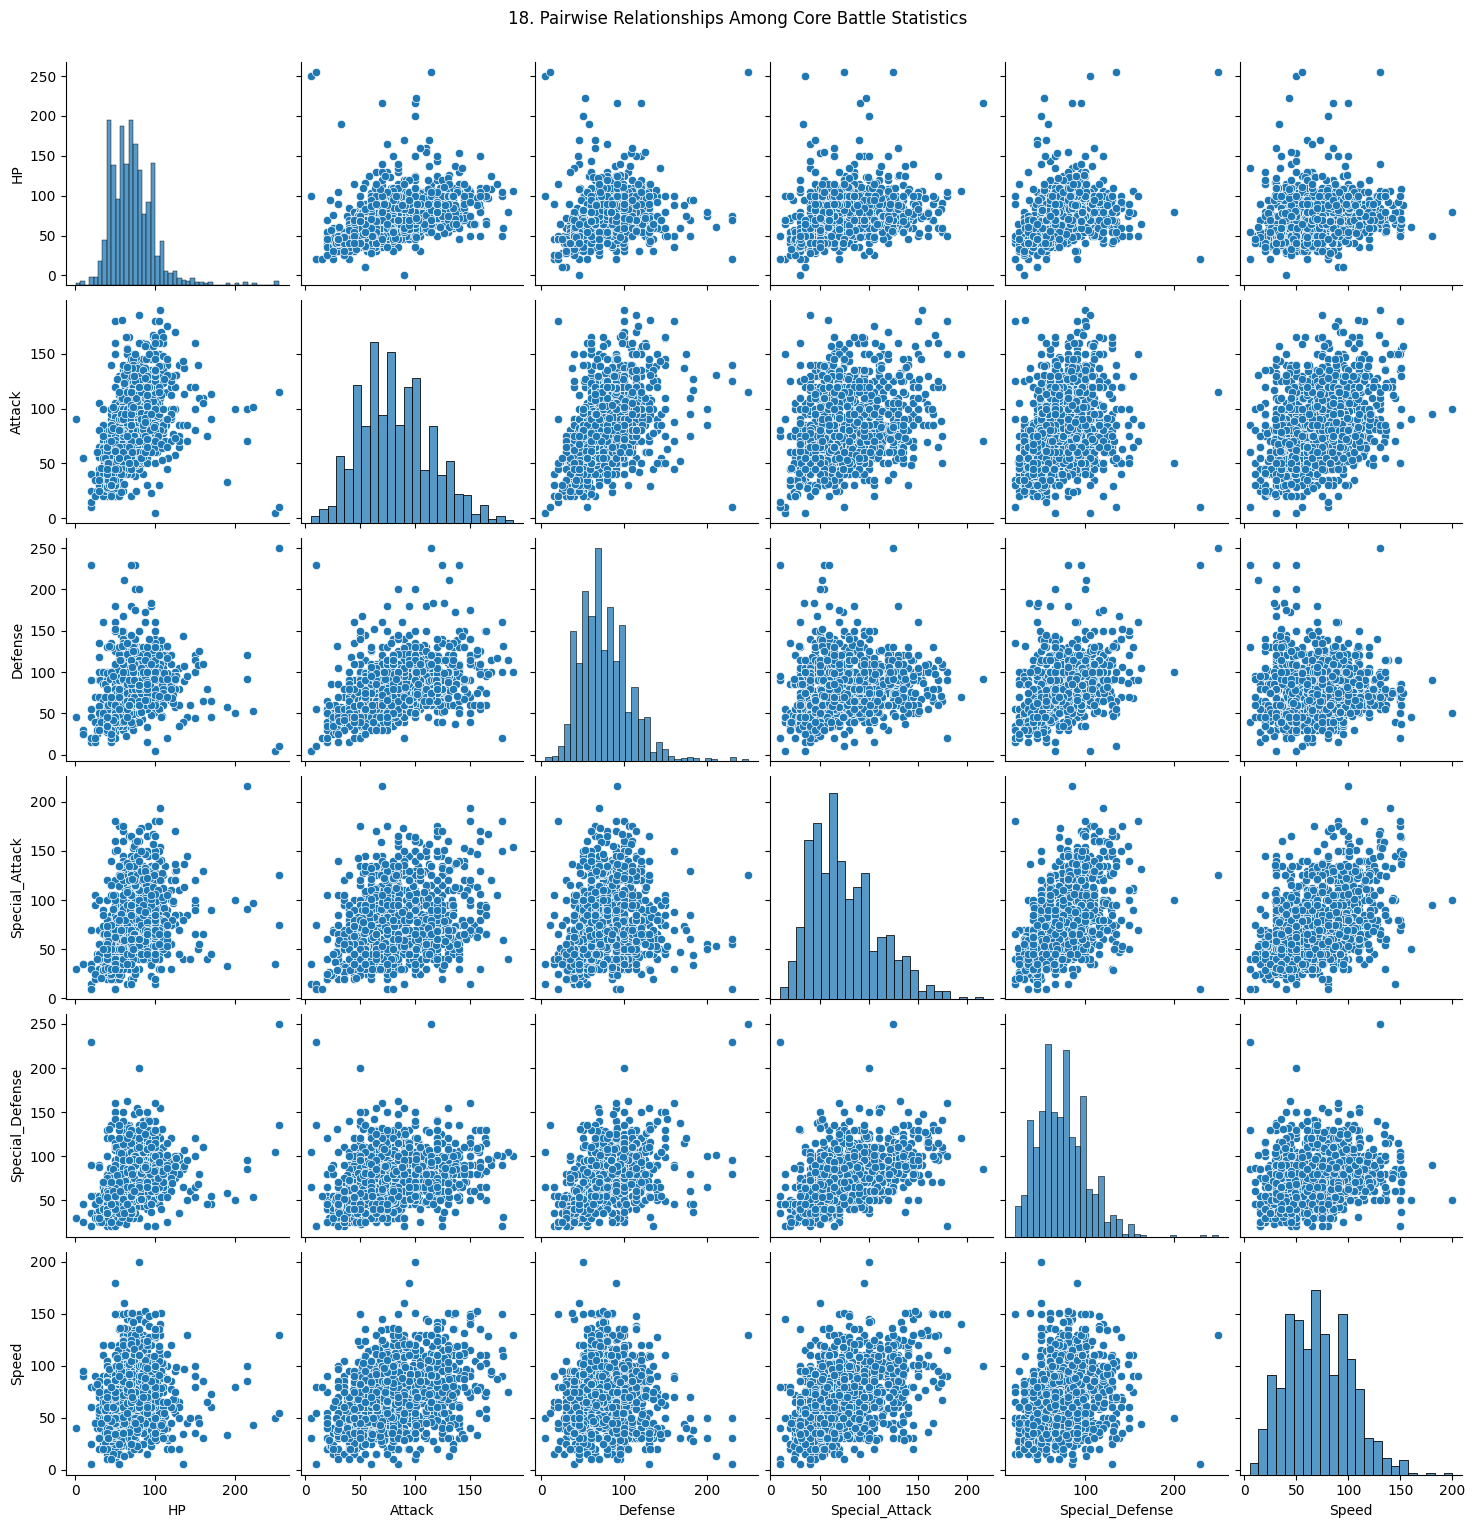

In [32]:
fig = plt.figure(figsize=(10,6))
sns.pairplot(df[['HP','Attack','Defense','Special_Attack','Special_Defense','Speed']])
plt.suptitle(f'{plot_no}. Pairwise Relationships Among Core Battle Statistics', y=1.02)
plt.show()
plot_no += 1

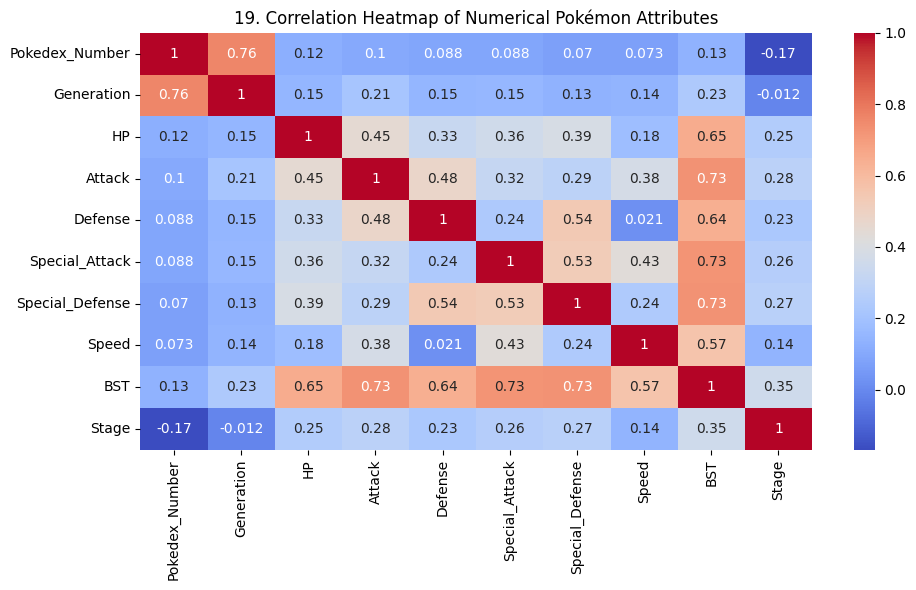

In [33]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Pokémon Attributes')
show_fig()
plot_no += 1

# Model Training

## Create copy of dataset

In [34]:
data = df.copy()

## Remove missing values

In [35]:
data = data.dropna()

## Define target column

In [36]:
target = "Stage"

## Create feature and target datasets

In [37]:
X = data.drop(columns=[target, "Pokemon_Name"], errors="ignore")
y = data[target]

## Find numeric and categorical columns

In [38]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

## Create preprocessing pipeline

In [39]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Split the dataset

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Build upgraded Gradient Boosting model

In [41]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

## Train the model

In [42]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict on test data

In [43]:
y_pred = model.predict(X_test)

## Print model accuracy

In [44]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score : {accuracy*100:.2f}%")

Accuracy Score : 79.05%


## Print classification report

In [45]:
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))


Classification Report

              precision    recall  f1-score   support

           1       0.88      0.86      0.87       132
           2       0.67      0.80      0.73        88
           3       0.84      0.48      0.62        33

    accuracy                           0.79       253
   macro avg       0.80      0.71      0.74       253
weighted avg       0.80      0.79      0.79       253



## Plot confusion matrix

<Figure size 800x600 with 0 Axes>

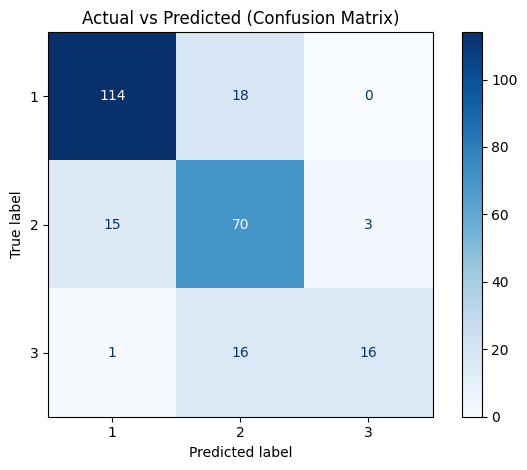

In [46]:
fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)
plt.title("Actual vs Predicted (Confusion Matrix)")
plt.tight_layout()
plt.show()